In [4]:
# ── Imports ───────────────────────────────────────────────────────────────────
import json
import math
import warnings
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, f1_score, roc_auc_score,
    precision_score, recall_score, confusion_matrix,
    average_precision_score,
    ConfusionMatrixDisplay
)


warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print('Imports OK')


Device: cuda
Imports OK


In [ ]:
# ── Data Loading — CSV + JSONL ─────────────────────────────────────────────────

# 1. Tabular CSV (GBDT baseline için)
df_mal = pd.read_csv('krono_malware.csv')
df_ben = pd.read_csv('krono_benign.csv', engine='python')
df_csv = pd.concat([df_mal, df_ben], ignore_index=True)
print(f'CSV shape: {df_csv.shape}  |  Malware: {len(df_mal)}  Benign: {len(df_ben)}')

# 2. Seq-log JSONL (Transformer için — KronoDroid train/val)
def load_jsonl(path):
    records = []
    with open(path, encoding='utf-8') as f:
        for line in f:
            records.append(json.loads(line))
    return records

seq_mal = load_jsonl('krono_malware_seqlogs.jsonl')
seq_ben = load_jsonl('krono_benign_seqlogs.jsonl')
seq_all = seq_mal + seq_ben
print(f'KronoDroid JSONL — Malware: {len(seq_mal)}  Benign: {len(seq_ben)}  Toplam: {len(seq_all)}')

# 3. Seq-log → DataFrame (KronoDroid)
df_seq = pd.DataFrame([
    {
        'package_name'       : r['package_name'],
        'label'              : r['label'],
        'session_duration_ms': r['session_duration_ms'],
        'seq_log'            : r['seq_log'],
    }
    for r in seq_all
])
df_seq['label_bin'] = (df_seq['label'] == 'malware').astype(int)

seq_lens = df_seq['seq_log'].apply(len)
print(f'\nSeq length stats:')
print(f'  min={seq_lens.min()}  max={seq_lens.max()}  '
      f'median={seq_lens.median():.0f}  mean={seq_lens.mean():.1f}  '
      f'p95={seq_lens.quantile(0.95):.0f}  p99={seq_lens.quantile(0.99):.0f}')
print(f'  >128: {(seq_lens > 128).sum()} ({100*(seq_lens>128).mean():.1f}%)'
      f'  >256: {(seq_lens > 256).sum()} ({100*(seq_lens>256).mean():.1f}%)')

# 4. AndroZoo — temporal test set (JSONL)
seq_az_mal = load_jsonl('androzoo/androzoo_malware_seqlogs.jsonl')
seq_az_ben = load_jsonl('androzoo/androzoo_benign_seqlogs.jsonl')

df_androzoo_seq = pd.DataFrame([
    {
        'package_name'       : r['package_name'],
        'label'              : r['label'],
        'session_duration_ms': r['session_duration_ms'],
        'seq_log'            : r['seq_log'],
    }
    for r in seq_az_mal + seq_az_ben
])
df_androzoo_seq['label_bin'] = (df_androzoo_seq['label'] == 'malware').astype(int)
print(f'\nAndroZoo JSONL — Malware: {len(seq_az_mal)}  Benign: {len(seq_az_ben)}  Toplam: {len(df_androzoo_seq)}')

# Histogram
plt.figure(figsize=(8, 3))
seq_lens.hist(bins=50, color='steelblue', edgecolor='white')
plt.axvline(128, color='red',    linestyle='--', label='reference length=128')
plt.axvline(256, color='orange', linestyle='--', label='selected MAX_SEQ_LEN=256')
plt.xlabel('Sequence Length')
plt.ylabel('Count')
plt.title('Event Sequence Length Distribution (KronoDroid)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── Vocabulary & Tokenization ─────────────────────────────────────────────────
# Akademik deney protokolü:
#   - KronoDroid: stratified train/val split (AndroZoo dokunulmaz, temporal test)
#   - Vocabulary ve n-gram sözlüğü SADECE train split üzerinden öğrenilir.
#   - AndroZoo'daki bilinmeyen tag'ler PAD'e düşer (vocabulary dışı).

TAGS = [
    # ── MALWARE-EXCLUSIVE (10 aktif) ────────────────────────────────────────
    'KEYLOG',
    'PKG_DISABLE',
    'PHONE_STATE_LISTEN',
    'PERM_ADMIN_REQ',
    'KEYSTORE_EXFIL',
    'WEBVIEW_JS_BRIDGE',   'WEBVIEW_JS_EXEC',
    'DEX_LOAD_MEMORY',
    'FILE_ENCRYPT_BULK',
    'ANTI_VM_PROPS',
    # ── BENIGN-EXCLUSIVE (4 aktif) ──────────────────────────────────────────
    'ANALYTICS_LOG',
    'SOCIAL_SHARE',
    'MEDIA_PLAY',          'NOTIF_POST_LEGIT',
    # ── NETWORK (6 aktif) ───────────────────────────────────────────────────
    'NET_HTTP_GET',        'NET_HTTP_POST',
    'NET_SOCKET_TCP',      'NET_SOCKET_UDP',
    'NET_DNS_LOOKUP',      'NET_SSL_BYPASS',
    # ── CRYPTO (7 aktif) ────────────────────────────────────────────────────
    'CRYPTO_AES',          'CRYPTO_RSA',
    'CRYPTO_HASH_MD5',     'CRYPTO_HASH_SHA',
    'CRYPTO_BASE64_ENC',   'CRYPTO_BASE64_DEC',    'CRYPTO_KEYGEN',
    # ── REFLECTION & LOADING (5 aktif) ──────────────────────────────────────
    'REFLECT_INVOKE',      'REFLECT_CLASS_LOAD',   'REFLECT_FIELD_ACCESS',
    'DEX_LOAD_FILE',       'NATIVE_LIB_LOAD',
    # ── SURVEILLANCE (7 aktif) ──────────────────────────────────────────────
    'SURV_DEVICE_ID',
    'SURV_LOCATION_GPS',   'SURV_LOCATION_NET',
    'SURV_CONTACT_READ',   'SURV_SMS_READ',        'SURV_CALL_LOG',
    'SURV_MIC_RECORD',
    # ── FILE OPERATIONS (4 aktif) ───────────────────────────────────────────
    'FILE_WRITE_INTERNAL', 'FILE_WRITE_EXTERNAL',
    'FILE_READ_SENSITIVE', 'FILE_DELETE',
    # ── EXECUTION (2 aktif) ─────────────────────────────────────────────────
    'EXEC_SHELL_CMD',      'EXEC_ROOT_CMD',
    # ── PERSISTENCE (4 aktif) ───────────────────────────────────────────────
    'PERSIST_BOOT_RECV',   'PERSIST_ALARM_REP',
    'PERSIST_JOB_SCHED',   'PERSIST_FG_SERVICE',
    # ── ANTI-ANALYSIS (4 aktif) ─────────────────────────────────────────────
    'ANTI_DEBUG',          'ANTI_EMULATOR',
    'ANTI_ROOT_CHECK',     'ANTI_SLEEP_LONG',
    # ── PACKAGE (1 aktif) ───────────────────────────────────────────────────
    'PKG_ENUMERATE',
    # ── IPC (3 aktif) ───────────────────────────────────────────────────────
    'IPC_BIND_SERVICE',    'IPC_SEND_BROADCAST',  'IPC_IMPLICIT_INTENT',
    # ── MEDIA & CONTENT (2 aktif) ───────────────────────────────────────────
    'MEDIA_PHOTO_ACCESS',  'MEDIA_VIDEO_ACCESS',
    # ── UI ABUSE (1 aktif) ──────────────────────────────────────────────────
    'CLIPBOARD_ACCESS',
    # ── C2 CHANNEL (1 aktif) ────────────────────────────────────────────────
    'REMOTE_CONFIG_FETCH',
]

# ── KronoDroid: Train / Val split ────────────────────────────────────────────
y_all = df_seq['label_bin'].values

idx_train, idx_val = train_test_split(
    np.arange(len(df_seq)), test_size=0.15, stratify=y_all, random_state=42
)

print(f'KronoDroid — Train: {len(idx_train)}  Val: {len(idx_val)}')
print(f'Train malware ratio: {y_all[idx_train].mean():.3f}')
print(f'Val   malware ratio: {y_all[idx_val].mean():.3f}')
print(f'AndroZoo test       : {len(df_androzoo_seq)} (temporal OOD test set)')
print(f'  malware ratio     : {df_androzoo_seq["label_bin"].mean():.3f}')

# TAGS listesindeki her tag train split'te gözlenmelidir.
_train_tags = set()
for _r in df_seq.iloc[idx_train]['seq_log']:
    for _e in _r:
        _train_tags.add(_e['tag'])

_missing_train_tags = [tag for tag in TAGS if tag not in _train_tags]
_extra_train_tags = sorted(_train_tags - set(TAGS))
assert not _missing_train_tags, f'TAGS içinde train splitte görülmeyen tag var: {_missing_train_tags}'
assert not _extra_train_tags, f'Train splitte TAGS listesinde olmayan tag var: {_extra_train_tags}'

PAD_ID     = 0
TAG2ID     = {tag: i+1 for i, tag in enumerate(TAGS)}
ID2TAG     = {v: k for k, v in TAG2ID.items()}
VOCAB_SIZE = len(TAGS) + 1   # active tags + PAD

ACTIVE_TAG_MASK = np.ones(len(TAGS), dtype=np.float32)
N_ACTIVE_TAGS = len(TAGS)

print(f'Active tags    : {N_ACTIVE_TAGS}')
print(f'Vocabulary size: {VOCAB_SIZE}  ({N_ACTIVE_TAGS} active tag + PAD)')

# Val ve AndroZoo'da vocabulary dışı tag varsa PAD'e düşer (informational).
def count_unknown_tags(df_sub):
    unknown = Counter()
    for _r in df_sub['seq_log']:
        for _e in _r:
            if _e['tag'] not in TAG2ID:
                unknown[_e['tag']] += 1
    return unknown

_val_unknown = count_unknown_tags(df_seq.iloc[idx_val])
_az_unknown  = count_unknown_tags(df_androzoo_seq)
print(f'Unknown val tags (KronoDroid): {sum(_val_unknown.values())} event / {len(_val_unknown)} tag')
print(f'Unknown test tags (AndroZoo) : {sum(_az_unknown.values())} event / {len(_az_unknown)} tag')

# Maksimum burst değeri sadece train split üzerinden ölçeklenir.
_MAX_BURST = max(
    (e.get('burst', 1) for r in df_seq.iloc[idx_train]['seq_log'] for e in r),
    default=30
)
_LOG_MAX_BURST = math.log1p(_MAX_BURST)
print(f'Max burst in train: {_MAX_BURST}  (log1p scale: {_LOG_MAX_BURST:.3f})')

MAL_EXCLUSIVE = [
    'KEYLOG','PKG_DISABLE','PHONE_STATE_LISTEN','PERM_ADMIN_REQ',
    'KEYSTORE_EXFIL','WEBVIEW_JS_BRIDGE','WEBVIEW_JS_EXEC','DEX_LOAD_MEMORY',
    'FILE_ENCRYPT_BULK','ANTI_VM_PROPS',
]
BEN_EXCLUSIVE = [
    'ANALYTICS_LOG','SOCIAL_SHARE','MEDIA_PLAY','NOTIF_POST_LEGIT',
]

# ── N-gram Vocabulary (sadece train split) ────────────────────────────────────
N_BIGRAMS  = 150
N_TRIGRAMS = 100
N_NGRAMS   = N_BIGRAMS + N_TRIGRAMS   # 250

_bigram_cnt  = Counter()
_trigram_cnt = Counter()
for _r in df_seq.iloc[idx_train]['seq_log']:
    _tags = [_e['tag'] for _e in _r if _e['tag'] in TAG2ID]
    for _i in range(len(_tags) - 1):
        _bigram_cnt[(_tags[_i], _tags[_i+1])] += 1
    for _i in range(len(_tags) - 2):
        _trigram_cnt[(_tags[_i], _tags[_i+1], _tags[_i+2])] += 1

TOP_BIGRAMS  = [bg for bg, _ in _bigram_cnt.most_common(N_BIGRAMS)]
TOP_TRIGRAMS = [tg for tg, _ in _trigram_cnt.most_common(N_TRIGRAMS)]
BIGRAM2ID    = {bg: i           for i, bg in enumerate(TOP_BIGRAMS)}
TRIGRAM2ID   = {tg: i+N_BIGRAMS for i, tg in enumerate(TOP_TRIGRAMS)}

print(f'\nN-gram vocabulary: {len(TOP_BIGRAMS)} bigrams + {len(TOP_TRIGRAMS)} trigrams = {N_NGRAMS} features')
print(f'  En sık bigram-5  : {TOP_BIGRAMS[:5]}')
print(f'  En sık trigram-5 : {TOP_TRIGRAMS[:5]}')

def encode_seq(seq_log, session_duration_ms, max_len=256):
    dur    = max(session_duration_ms, 1)
    events = seq_log[:max_len]

    tag_ids    = np.zeros(max_len,   dtype=np.int64)
    time_vals  = np.zeros(max_len,   dtype=np.float32)
    delta_vals = np.zeros(max_len,   dtype=np.float32)
    burst_vals = np.zeros(max_len,   dtype=np.float32)
    attn_mask  = np.ones(max_len,    dtype=bool)
    tag_freq   = np.zeros(len(TAGS), dtype=np.float32)
    ngram_feat = np.zeros(N_NGRAMS,  dtype=np.float32)

    prev_ms = 0
    raw_tags = []
    for i, ev in enumerate(events):
        tag = ev['tag']
        tid = TAG2ID.get(tag, PAD_ID)
        cur_ms = ev['ms']
        burst = ev.get('burst', 1)
        tag_ids[i] = tid
        time_vals[i] = min(cur_ms / dur, 1.0)
        delta_vals[i] = min(max(cur_ms - prev_ms, 0) / dur, 1.0)
        burst_vals[i] = min(math.log1p(burst) / _LOG_MAX_BURST, 1.0)
        attn_mask[i] = False
        if tid > 0:
            tag_freq[tid - 1] += burst
            raw_tags.append(tag)
        prev_ms = cur_ms

    for i in range(len(raw_tags) - 1):
        bg = (raw_tags[i], raw_tags[i+1])
        if bg in BIGRAM2ID:
            ngram_feat[BIGRAM2ID[bg]] += 1.0

    for i in range(len(raw_tags) - 2):
        tg = (raw_tags[i], raw_tags[i+1], raw_tags[i+2])
        if tg in TRIGRAM2ID:
            ngram_feat[TRIGRAM2ID[tg]] += 1.0

    total = tag_freq.sum()
    if total > 0:
        tag_freq /= total

    ng_total = ngram_feat.sum()
    if ng_total > 0:
        ngram_feat /= ng_total

    return tag_ids, time_vals, delta_vals, burst_vals, attn_mask, tag_freq, ngram_feat

print('encode_seq OK (61 active tag_ids, time_vals, delta_vals, burst_vals, attn_mask, tag_freq, ngram_feat)')

In [ ]:
# ── PyTorch Dataset & DataLoader ──────────────────────────────────────────────
MAX_SEQ_LEN = 256

class SeqLogDataset(Dataset):
    def __init__(self, df, max_len=MAX_SEQ_LEN):
        self.df      = df.reset_index(drop=True)
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        tag_ids, time_vals, delta_vals, burst_vals, attn_mask, tag_freq, ngram_feat = encode_seq(
            row['seq_log'], row['session_duration_ms'], self.max_len
        )
        return (
            torch.tensor(tag_ids,    dtype=torch.long),
            torch.tensor(time_vals,  dtype=torch.float),
            torch.tensor(delta_vals, dtype=torch.float),
            torch.tensor(burst_vals, dtype=torch.float),
            torch.tensor(attn_mask,  dtype=torch.bool),
            torch.tensor(tag_freq,   dtype=torch.float),
            torch.tensor(ngram_feat, dtype=torch.float),
            torch.tensor(row['label_bin'], dtype=torch.float),
        )

BATCH_SIZE = 64

def dynamic_collate(batch):
    tag_ids, time_v, delta_v, burst_v, attn_m, tag_f, ngram_f, labels = zip(*batch)

    real_lens = [(~m).sum().item() for m in attn_m]
    max_len   = max(real_lens)

    def pad_seq(t):
        return t[:max_len]

    tag_ids_p  = torch.stack([pad_seq(t) for t in tag_ids])
    time_v_p   = torch.stack([pad_seq(t) for t in time_v])
    delta_v_p  = torch.stack([pad_seq(t) for t in delta_v])
    burst_v_p  = torch.stack([pad_seq(t) for t in burst_v])
    attn_m_p   = torch.stack([pad_seq(t) for t in attn_m])
    tag_f_p    = torch.stack(list(tag_f))
    ngram_f_p  = torch.stack(list(ngram_f))
    labels_p   = torch.stack(list(labels))
    return tag_ids_p, time_v_p, delta_v_p, burst_v_p, attn_m_p, tag_f_p, ngram_f_p, labels_p

train_ds = SeqLogDataset(df_seq.iloc[idx_train])
val_ds   = SeqLogDataset(df_seq.iloc[idx_val])
test_ds  = SeqLogDataset(df_androzoo_seq)   # AndroZoo temporal test set

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=2, pin_memory=True, collate_fn=dynamic_collate)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=2, pin_memory=True, collate_fn=dynamic_collate)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=2, pin_memory=True, collate_fn=dynamic_collate)
print('DataLoaders ready.  (train/val=KronoDroid, test=AndroZoo temporal)')
print(f'  train: {len(train_ds)}  val: {len(val_ds)}  test(AndroZoo): {len(test_ds)}')

In [8]:
# ── Self-Supervised Pretraining — Dataset & Model ─────────────────────────────
#
# v3 → v5 strateji değişikliği:
#   v4: Masked Diffusion ile sentetik veri üretimi  → iyileşme görülmedi
#   v5: Self-supervised pretraining → supervised fine-tuning
#       Üç görev: MEM + NEP + TBP
#
# Aktif-tag vocabulary kullanılır; hiç tetiklenmeyen tag sınıfları MEM/NEP çıktısından çıkarılmıştır.
# PretrainDataset sequence özelliklerini kullanır; ngram_feat bu aşamada yok sayılır.

MASK_ID        = VOCAB_SIZE          # active_vocab + PAD sonrası [MASK] id
PRETRAIN_VOCAB = VOCAB_SIZE + 1      # active_vocab + PAD + MASK
N_TIME_BUCKETS = 10
MASK_PROB      = 0.15
MASK_REPLACE   = 0.80
MASK_RANDOM    = 0.10


class PretrainDataset(Dataset):
    def __init__(self, df, max_len=MAX_SEQ_LEN, mask_prob=MASK_PROB):
        self.df        = df.reset_index(drop=True)
        self.max_len   = max_len
        self.mask_prob = mask_prob

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # encode_seq 7 değer döndürür; ngram_feat pretrain için kullanılmaz
        tag_ids, time_vals, delta_vals, burst_vals, attn_mask, _, _ = encode_seq(
            row['seq_log'], row['session_duration_ms'], self.max_len
        )

        # Zaman kovası: time_vals [0,1] → ondalık (0-9), PAD → -1
        time_buckets = np.full(self.max_len, -1, dtype=np.int64)
        non_pad = ~attn_mask
        if non_pad.any():
            buckets = np.floor(time_vals[non_pad] * N_TIME_BUCKETS).astype(int)
            time_buckets[non_pad] = np.clip(buckets, 0, N_TIME_BUCKETS - 1)

        # BERT-tarzı maskeleme (MEM için)
        tag_ids_orig   = tag_ids.copy()
        tag_ids_masked = tag_ids.copy()
        mem_mask       = np.zeros(self.max_len, dtype=bool)

        non_pad_idx = np.where(non_pad)[0]
        n_mask      = max(1, int(len(non_pad_idx) * self.mask_prob))
        selected    = np.random.choice(non_pad_idx, size=n_mask, replace=False)
        mem_mask[selected] = True

        for pos in selected:
            r = np.random.random()
            if r < MASK_REPLACE:
                tag_ids_masked[pos] = MASK_ID
            elif r < MASK_REPLACE + MASK_RANDOM:
                tag_ids_masked[pos] = np.random.randint(1, VOCAB_SIZE)

        return (
            torch.tensor(tag_ids_masked, dtype=torch.long),
            torch.tensor(tag_ids_orig,   dtype=torch.long),
            torch.tensor(mem_mask,       dtype=torch.bool),
            torch.tensor(time_vals,      dtype=torch.float),
            torch.tensor(delta_vals,     dtype=torch.float),
            torch.tensor(burst_vals,     dtype=torch.float),
            torch.tensor(attn_mask,      dtype=torch.bool),
            torch.tensor(time_buckets,   dtype=torch.long),
        )


class EventSequencePretrainer(nn.Module):
    """
    Self-supervised ön-eğitim modeli — üç görev: MEM + NEP + TBP.
    Sadece embedding/projection/Transformer encoder downstream modele aktarılır;
    MEM/NEP/TBP head'leri ön-eğitim görevi için kullanılır ve sonra atılır.
    embed_dim=256, nhead=8, num_layers=3, ff_dim=512.
    """
    def __init__(
        self,
        vocab_size  = PRETRAIN_VOCAB,
        embed_dim   = 256,
        nhead       = 8,
        num_layers  = 3,
        ff_dim      = 512,
        dropout     = 0.10,
    ):
        super().__init__()
        self.embed_dim = embed_dim

        self.tag_emb = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
        self.time_proj = nn.Sequential(
            nn.Linear(1, embed_dim // 2), nn.GELU(),
            nn.Linear(embed_dim // 2, embed_dim),
        )
        self.delta_proj = nn.Sequential(
            nn.Linear(1, embed_dim // 2), nn.GELU(),
            nn.Linear(embed_dim // 2, embed_dim),
        )
        self.burst_proj = nn.Sequential(
            nn.Linear(1, embed_dim // 2), nn.GELU(),
            nn.Linear(embed_dim // 2, embed_dim),
        )
        self.input_norm = nn.LayerNorm(embed_dim)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=nhead,
            dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        self.mem_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
            nn.Linear(embed_dim, VOCAB_SIZE),
        )
        self.nep_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
            nn.Linear(embed_dim, VOCAB_SIZE),
        )
        self.tbp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim // 2),
            nn.GELU(),
            nn.Linear(embed_dim // 2, N_TIME_BUCKETS),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, std=0.02)
                if m.padding_idx is not None:
                    m.weight.data[m.padding_idx].zero_()

    def forward(self, tag_ids_masked, time_vals, delta_vals, burst_vals, attn_mask):
        tag_e   = self.tag_emb(tag_ids_masked)
        time_e  = self.time_proj(time_vals.unsqueeze(-1))
        delta_e = self.delta_proj(delta_vals.unsqueeze(-1))
        burst_e = self.burst_proj(burst_vals.unsqueeze(-1))
        x       = self.input_norm(tag_e + time_e + delta_e + burst_e)
        out     = self.encoder(x, src_key_padding_mask=attn_mask)
        return self.mem_head(out), self.nep_head(out), self.tbp_head(out)


pretrainer = EventSequencePretrainer().to(DEVICE)
n_params   = sum(p.numel() for p in pretrainer.parameters() if p.requires_grad)
print(f'EventSequencePretrainer — trainable params: {n_params:,}')
print(f'  embed_dim=256  nhead=8  num_layers=3  ff_dim=512  dropout=0.10')
print(f'  Görevler: MEM + NEP + TBP')
print(f'  MASK_ID={MASK_ID}  PRETRAIN_VOCAB={PRETRAIN_VOCAB}  N_TIME_BUCKETS={N_TIME_BUCKETS}')
print(f'  PretrainDataset: active vocabulary, encode_seq 7 değer (ngram_feat yok sayılır)')


EventSequencePretrainer — trainable params: 1,896,966
  embed_dim=256  nhead=8  num_layers=3  ff_dim=512  dropout=0.10
  Görevler: MEM + NEP + TBP
  MASK_ID=62  PRETRAIN_VOCAB=63  N_TIME_BUCKETS=10
  PretrainDataset: active vocabulary, encode_seq 7 değer (ngram_feat yok sayılır)


Pretraining: 8335 sequence  (8335 train,  val/test dokunulmadı)
PRETRAIN_EPOCHS=150

 Epoch        LR     Total      MEM      NEP      TBP
----------------------------------------------------------
     1  3.00e-04    4.3302   2.3058   1.8443   0.3603
    10  2.97e-04    3.2080   1.8237   1.3367   0.0951
    20  2.87e-04    2.9295   1.6730   1.2229   0.0671
    30  2.72e-04    2.7778   1.5931   1.1579   0.0537
    40  2.52e-04    2.6620   1.5237   1.1161   0.0443
    50  2.28e-04    2.5874   1.4857   1.0827   0.0380
    60  2.00e-04    2.5021   1.4332   1.0525   0.0328
    70  1.70e-04    2.4460   1.4019   1.0297   0.0288
    80  1.40e-04    2.3820   1.3631   1.0065   0.0250
    90  1.10e-04    2.3225   1.3239   0.9872   0.0228
   100  8.25e-05    2.2654   1.2922   0.9639   0.0187
   110  5.80e-05    2.2161   1.2613   0.9465   0.0166
   120  3.77e-05    2.1641   1.2292   0.9276   0.0145
   130  2.25e-05    2.1227   1.2014   0.9146   0.0136
   140  1.32e-05    2.1175   1.2026   0.9084  

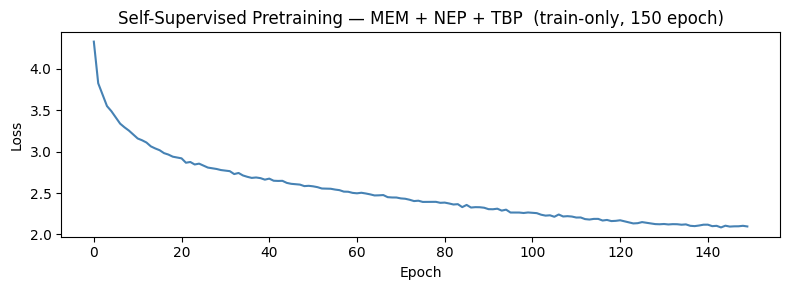

Pretrained encoder ağırlıkları supervised model ve SSL ablation karşılaştırması için hazır.


In [9]:
# ── Self-Supervised Pretraining — Eğitim Döngüsü ──────────────────────────────
#
# Sadece train sequence'ları kullanılır (LABEL YOK; val/test dokunulmaz).
# L_total = L_mem + L_nep + λ_tbp × L_tbp
#


PRETRAIN_EPOCHS  = 150
PRETRAIN_LR      = 3e-4
PRETRAIN_BATCH   = 2
TBP_WEIGHT       = 0.5

df_pretrain  = df_seq.iloc[idx_train].reset_index(drop=True)
pretrain_ds  = PretrainDataset(df_pretrain)

def pretrain_collate(batch):
    tag_m, tag_o, mem_mask, time_v, delta_v, burst_v, attn_m, tbuckets = zip(*batch)
    real_lens = [(~m).sum().item() for m in attn_m]
    max_len   = max(real_lens)
    def pad(t, pv=0): return t[:max_len]
    def pad_bool(t, pv=True): return t[:max_len]
    return (
        torch.stack([pad(t)      for t in tag_m]),
        torch.stack([pad(t)      for t in tag_o]),
        torch.stack([pad_bool(t, False) for t in mem_mask]),
        torch.stack([pad(t)      for t in time_v]),
        torch.stack([pad(t)      for t in delta_v]),
        torch.stack([pad(t)      for t in burst_v]),
        torch.stack([pad_bool(t) for t in attn_m]),
        torch.stack([pad(t, -1)  for t in tbuckets]),
    )

pretrain_dl  = DataLoader(pretrain_ds, batch_size=PRETRAIN_BATCH, shuffle=True,
                          num_workers=2, pin_memory=True, collate_fn=pretrain_collate)
print(f'Pretraining: {len(pretrain_ds)} sequence  '
      f'({len(idx_train)} train,  val/test dokunulmadı)')
print(f'PRETRAIN_EPOCHS={PRETRAIN_EPOCHS}')

pretrain_opt   = AdamW(pretrainer.parameters(), lr=PRETRAIN_LR, weight_decay=1e-2)
pretrain_sched = CosineAnnealingLR(pretrain_opt, T_max=PRETRAIN_EPOCHS, eta_min=1e-5)

mem_crit = nn.CrossEntropyLoss(ignore_index=PAD_ID)
nep_crit = nn.CrossEntropyLoss(ignore_index=PAD_ID)
tbp_crit = nn.CrossEntropyLoss(ignore_index=-1)

pretrain_history = []

print(f"\n{'Epoch':>6}  {'LR':>8}  {'Total':>8}  {'MEM':>7}  {'NEP':>7}  {'TBP':>7}")
print('-' * 58)

for epoch in range(1, PRETRAIN_EPOCHS + 1):
    pretrainer.train()
    tot, mem_t, nep_t, tbp_t, nb = 0.0, 0.0, 0.0, 0.0, 0

    for batch in pretrain_dl:
        (tag_masked, tag_orig, mem_mask,
         time_v, delta_v, burst_v,
         attn_mask, time_buckets) = [b.to(DEVICE) for b in batch]

        mem_logits, nep_logits, tbp_logits = pretrainer(
            tag_masked, time_v, delta_v, burst_v, attn_mask
        )
        B, L, V = mem_logits.shape

        mem_targets = tag_orig.view(B * L).clone()
        mem_targets[~mem_mask.view(B * L)] = PAD_ID
        l_mem = mem_crit(mem_logits.view(B * L, V), mem_targets)

        nep_pred    = nep_logits[:, :-1, :].reshape(-1, V)
        nep_targets = tag_orig[:, 1:].reshape(-1)
        l_nep = nep_crit(nep_pred, nep_targets)

        l_tbp = tbp_crit(tbp_logits.view(B * L, N_TIME_BUCKETS),
                         time_buckets.view(B * L))

        loss = l_mem + l_nep + TBP_WEIGHT * l_tbp
        pretrain_opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(pretrainer.parameters(), 1.0)
        pretrain_opt.step()

        tot   += loss.item()
        mem_t += l_mem.item()
        nep_t += l_nep.item()
        tbp_t += l_tbp.item()
        nb    += 1

    pretrain_sched.step()
    pretrain_history.append(tot / nb)

    if epoch % 10 == 0 or epoch == 1:
        lr = pretrain_sched.get_last_lr()[0]
        print(f'{epoch:>6}  {lr:>8.2e}  {tot/nb:>8.4f}  '
              f'{mem_t/nb:>7.4f}  {nep_t/nb:>7.4f}  {tbp_t/nb:>7.4f}')

print('\nÖn-eğitim tamamlandı.')

plt.figure(figsize=(8, 3))
plt.plot(pretrain_history, color='steelblue')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Self-Supervised Pretraining — MEM + NEP + TBP  (train-only, 150 epoch)')
plt.tight_layout(); plt.show()

ssl_encoder_state = {k: v.detach().cpu().clone() for k, v in pretrainer.state_dict().items()}
print('Pretrained encoder ağırlıkları supervised model ve SSL ablation karşılaştırması için hazır.')


In [10]:
# ── MalwareTransformer — Proposed Hybrid Model ───────────────────────────────
#
# Önerilen model:
#   SSL-pretrained Transformer encoder + BiLSTM + frequency branch + n-gram branch.
#   N-gram branch, Transformer'ın örtük öğrendiği geçiş örüntülerini açık sayısal
#   özellik olarak verir. Füzyon: [cls | tf_mean | optional lstm | freq | optional ngram].
#
# Ana ayar:
#   dropout=0.25, token_drop=0.05, noise_sigma=0.05
#   LSTM: last_hidden + mean_pool (residual)

class MalwareTransformer(nn.Module):
    """
    Hibrit: SSL-Pretrained Transformer + optional BiLSTM + Freq + optional N-gram Branch.

    Default model full proposed architecture'dır:
      Transformer Branch → CLS + mean-pool   (2×256)
      BiLSTM Branch      → last + mean-pool residual (256)
      Freq Branch        → tag frequency vector (256)
      N-gram Branch      → bigram/trigram vector (256)
    """
    def __init__(
        self,
        vocab_size    = PRETRAIN_VOCAB,
        embed_dim     = 256,
        nhead         = 8,
        num_layers    = 3,
        ff_dim        = 512,
        dropout       = 0.25,
        token_drop_p  = 0.05,
        lstm_hidden   = 128,
        lstm_layers   = 2,
        lstm_dropout  = 0.25,
        noise_sigma   = 0.05,
        n_tags        = len(TAGS),
        n_ngrams      = N_NGRAMS,
        use_bilstm    = True,
        use_ngram     = True,
    ):
        super().__init__()
        self.embed_dim    = embed_dim
        self.token_drop_p = token_drop_p
        self.noise_sigma  = noise_sigma
        self.use_bilstm   = use_bilstm
        self.use_ngram    = use_ngram

        # ── Ortak Embedding (pretrained) ──────────────────────────────────────
        self.tag_emb = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
        self.time_proj = nn.Sequential(
            nn.Linear(1, embed_dim // 2), nn.GELU(),
            nn.Linear(embed_dim // 2, embed_dim),
        )
        self.delta_proj = nn.Sequential(
            nn.Linear(1, embed_dim // 2), nn.GELU(),
            nn.Linear(embed_dim // 2, embed_dim),
        )
        self.burst_proj = nn.Sequential(
            nn.Linear(1, embed_dim // 2), nn.GELU(),
            nn.Linear(embed_dim // 2, embed_dim),
        )
        self.input_norm = nn.LayerNorm(embed_dim)

        # ── Transformer Branch (pretrained) ──────────────────────────────────
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=nhead,
            dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        # ── Optional BiLSTM Branch ───────────────────────────────────────────
        if self.use_bilstm:
            self.bilstm = nn.LSTM(
                input_size    = embed_dim,
                hidden_size   = lstm_hidden,
                num_layers    = lstm_layers,
                dropout       = lstm_dropout if lstm_layers > 1 else 0.0,
                bidirectional = True,
                batch_first   = True,
            )
            self.lstm_norm = nn.LayerNorm(lstm_hidden * 2)

        # ── Frequency Branch ─────────────────────────────────────────────────
        self.register_buffer('active_mask', torch.tensor(ACTIVE_TAG_MASK))
        self.freq_proj = nn.Sequential(
            nn.Linear(n_tags, embed_dim),
            nn.GELU(),
            nn.LayerNorm(embed_dim),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
            nn.LayerNorm(embed_dim),
        )

        # ── Optional N-gram Branch ───────────────────────────────────────────
        if self.use_ngram:
            self.ngram_proj = nn.Sequential(
                nn.Linear(n_ngrams, embed_dim),
                nn.GELU(),
                nn.LayerNorm(embed_dim),
                nn.Dropout(dropout),
                nn.Linear(embed_dim, embed_dim),
                nn.GELU(),
                nn.LayerNorm(embed_dim),
            )

        # ── Füzyon Kafası ─────────────────────────────────────────────────────
        fuse_parts = 3 + int(self.use_bilstm) + int(self.use_ngram)  # cls, tf_mean, freq + optional branches
        fuse_dim = embed_dim * fuse_parts
        self.head = nn.Sequential(
            nn.LayerNorm(fuse_dim),
            nn.Linear(fuse_dim, embed_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, 1),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, std=0.02)
                if m.padding_idx is not None:
                    m.weight.data[m.padding_idx].zero_()
            elif isinstance(m, nn.LSTM):
                for name, param in m.named_parameters():
                    if 'weight_ih' in name:
                        nn.init.xavier_uniform_(param.data)
                    elif 'weight_hh' in name:
                        nn.init.orthogonal_(param.data)
                    elif 'bias' in name:
                        nn.init.zeros_(param.data)

    def load_pretrained_encoder(self, pretrainer):
        """EventSequencePretrainer omurgasını aktarır (Transformer branch)."""
        self.tag_emb.load_state_dict(pretrainer.tag_emb.state_dict())
        self.time_proj.load_state_dict(pretrainer.time_proj.state_dict())
        self.delta_proj.load_state_dict(pretrainer.delta_proj.state_dict())
        self.burst_proj.load_state_dict(pretrainer.burst_proj.state_dict())
        self.encoder.load_state_dict(pretrainer.encoder.state_dict())
        print('Pretrained encoder ağırlıkları MalwareTransformer modeline aktarıldı.')
        trainable_branches = ['freq/head']
        if self.use_bilstm: trainable_branches.append('BiLSTM')
        if self.use_ngram:  trainable_branches.append('N-gram')
        print('Sıfırdan eğitilecek branch/head:', ', '.join(trainable_branches))

    def _apply_token_dropout(self, tag_ids, pad_mask):
        if not self.training or self.token_drop_p <= 0:
            return tag_ids, pad_mask
        non_pad   = ~pad_mask
        drop_mask = (torch.rand_like(tag_ids, dtype=torch.float) < self.token_drop_p) & non_pad
        new_tag_ids = tag_ids.clone()
        new_tag_ids[drop_mask] = PAD_ID
        return new_tag_ids, pad_mask | drop_mask

    def forward(self, tag_ids, time_vals, delta_vals, burst_vals, pad_mask,
                tag_freq, ngram_feat):
        B, L = tag_ids.shape
        tag_ids, pad_mask = self._apply_token_dropout(tag_ids, pad_mask)

        tag_e   = self.tag_emb(tag_ids)
        time_e  = self.time_proj(time_vals.unsqueeze(-1))
        delta_e = self.delta_proj(delta_vals.unsqueeze(-1))
        burst_e = self.burst_proj(burst_vals.unsqueeze(-1))
        x = self.input_norm(tag_e + time_e + delta_e + burst_e)

        if self.training and self.noise_sigma > 0:
            x = x + torch.randn_like(x) * self.noise_sigma

        cls       = self.cls_token.expand(B, -1, -1)
        x_tf      = torch.cat([cls, x], dim=1)
        cls_mask  = torch.zeros(B, 1, dtype=torch.bool, device=x.device)
        full_mask = torch.cat([cls_mask, pad_mask], dim=1)
        out_tf    = self.encoder(x_tf, src_key_padding_mask=full_mask)
        cls_out   = out_tf[:, 0, :]
        seq_out   = out_tf[:, 1:, :]
        non_pad   = (~pad_mask).float().unsqueeze(-1)
        tf_mean   = (seq_out * non_pad).sum(1) / non_pad.sum(1).clamp(min=1)

        features = [cls_out, tf_mean]

        if self.use_bilstm:
            real_lens = (~pad_mask).sum(dim=1).cpu().clamp(min=1)
            packed    = pack_padded_sequence(x, real_lens, batch_first=True,
                                             enforce_sorted=False)
            lstm_out_packed, (h_n, _) = self.bilstm(packed)
            lstm_last = torch.cat([h_n[-2], h_n[-1]], dim=-1)
            lstm_seq, _ = pad_packed_sequence(lstm_out_packed, batch_first=True)
            seq_len_out = lstm_seq.size(1)
            if seq_len_out < L:
                pad_zeros = torch.zeros(B, L - seq_len_out, lstm_seq.size(2),
                                        device=x.device)
                lstm_seq = torch.cat([lstm_seq, pad_zeros], dim=1)
            else:
                lstm_seq = lstm_seq[:, :L, :]
            lstm_mean = (lstm_seq * non_pad).sum(1) / non_pad.sum(1).clamp(min=1)
            features.append(self.lstm_norm(lstm_last + lstm_mean))

        masked_freq = tag_freq * self.active_mask
        features.append(self.freq_proj(masked_freq))

        if self.use_ngram:
            features.append(self.ngram_proj(ngram_feat))

        fused = torch.cat(features, dim=-1)
        return self.head(fused).squeeze(-1)


model = MalwareTransformer().to(DEVICE)
model.load_pretrained_encoder(pretrainer)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'MalwareTransformer — trainable params: {n_params:,}')
print(f'  Transformer: embed_dim=256  nhead=8  num_layers=3  ff_dim=512  dropout=0.25')
print(f'  BiLSTM: hidden=128 (bidir→256)  layers=2  lstm_dropout=0.25')
print(f'  LSTM çıktı: last_hidden + mean_pool (residual)')
print(f'  Diffusion noise: σ=0.05')
print(f'  N-gram branch: {N_NGRAMS} ({N_BIGRAMS} bigram + {N_TRIGRAMS} trigram) → 256')
print(f'  Füzyon: 5×256=1280 → 256 → 1')


Pretrained encoder ağırlıkları MalwareTransformer modeline aktarıldı.
Sıfırdan eğitilecek branch/head: freq/head, BiLSTM, N-gram
MalwareTransformer — trainable params: 3,033,601
  Transformer: embed_dim=256  nhead=8  num_layers=3  ff_dim=512  dropout=0.25
  BiLSTM: hidden=128 (bidir→256)  layers=2  lstm_dropout=0.25
  LSTM çıktı: last_hidden + mean_pool (residual)
  Diffusion noise: σ=0.05
  N-gram branch: 250 (150 bigram + 100 trigram) → 256
  Füzyon: 5×256=1280 → 256 → 1


Train — malware: 5514  benign: 2821  pos_weight: 0.512
Discriminatif LR — encoder: 2e-05  bilstm: 1.0e-04  head+freq+ngram: 2e-04
Gradual unfreeze: Transformer encoder ilk 5 epoch dondurulur

 Epoch     LR_enc   TrainLoss   ValLoss   TrainAUC   ValAUC    ValF1     Gap   Frozen
------------------------------------------------------------------------------------------------
  [Epoch 1-5] Transformer encoder donduruldu — BiLSTM+head+ngram açık
     1   5.60e-06      0.4503    0.3053     0.7350   0.8697   0.7657  -0.135      YES
     5   2.00e-05      0.2797    0.1788     0.9499   0.9642   0.8811  -0.014      YES
  [Epoch 6] Encoder açıldı — enc=2e-05  lstm=1.0e-04  head=2e-04
    10   1.99e-05      0.2368    0.1541     0.9781   0.9746   0.8950  +0.004       no
    15   1.95e-05      0.2129    0.1399     0.9892   0.9778   0.9101  +0.011       no
    20   1.89e-05      0.1976    0.1429     0.9940   0.9763   0.9164  +0.018       no
    25   1.80e-05      0.1855    0.1412     0.9974   0.9774 

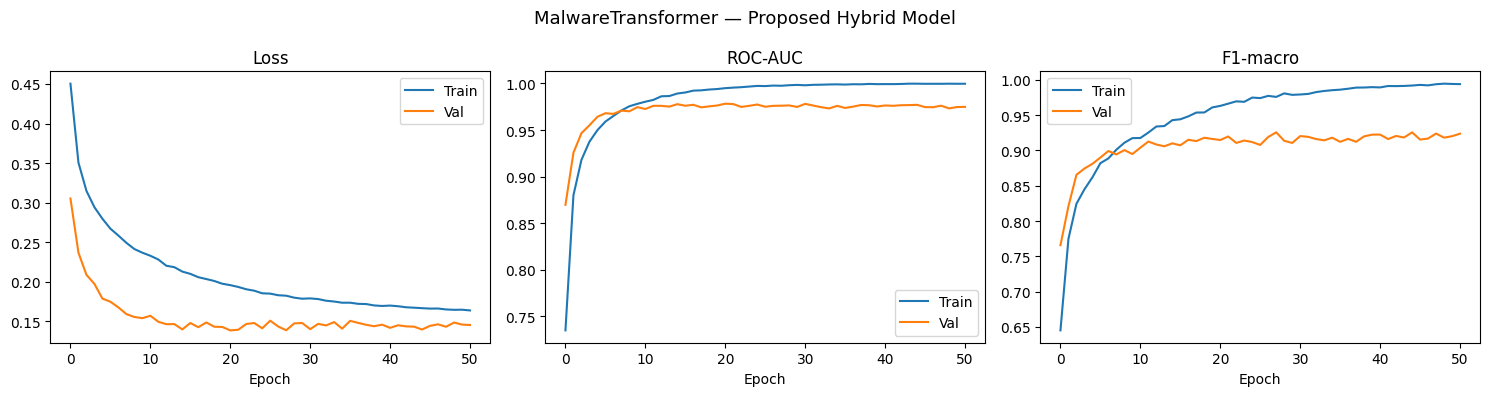

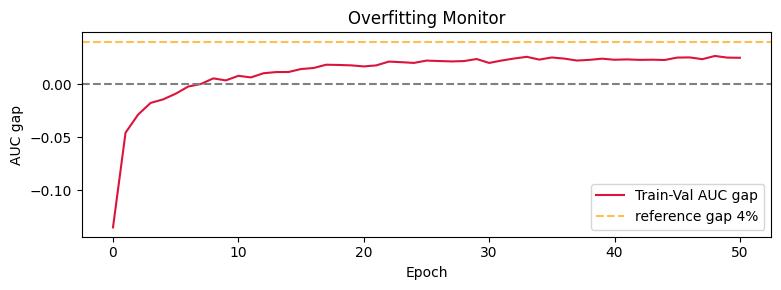

In [11]:
# ── Supervised Fine-tuning ───────────────────────────────────────────────────
#
# Clean fine-tuning policy:
#   - BCEWithLogitsLoss + train pos_weight
#   - Hafif label smoothing (ε=0.05)
#   - Sade regularization: dropout/token-drop/noise = 0.25/0.05/0.05
#   - Encoder düşük LR ile, task-specific branch/head daha yüksek LR ile eğitilir
#
# Parametre grupları:
#   encoder (pretrained) → ENCODER_LR=2e-5
#   bilstm               → LSTM_LR=1e-4
#   head + freq/ngram    → HEAD_LR=2e-4

EPOCHS        = 100
WEIGHT_DECAY  = 1e-2
PATIENCE      = 30
WARMUP_EPOCHS = 5
LABEL_SMOOTH  = 0.05
ENCODER_LR    = 2e-5
LSTM_LR       = 1e-4
HEAD_LR       = 2e-4
FREEZE_EPOCHS = 5

n_mal_train = int(y_all[idx_train].sum())
n_ben_train = len(idx_train) - n_mal_train
pos_w = torch.tensor(n_ben_train / n_mal_train, dtype=torch.float).to(DEVICE)
print(f'Train — malware: {n_mal_train}  benign: {n_ben_train}  pos_weight: {pos_w.item():.3f}')
print(f'Discriminatif LR — encoder: {ENCODER_LR:.0e}  bilstm: {LSTM_LR:.1e}  head+freq+ngram: {HEAD_LR:.0e}')
print(f'Gradual unfreeze: Transformer encoder ilk {FREEZE_EPOCHS} epoch dondurulur')

def set_encoder_grad(requires_grad: bool):
    for p in model.tag_emb.parameters():    p.requires_grad_(requires_grad)
    for p in model.time_proj.parameters():  p.requires_grad_(requires_grad)
    for p in model.delta_proj.parameters(): p.requires_grad_(requires_grad)
    for p in model.burst_proj.parameters(): p.requires_grad_(requires_grad)
    for p in model.encoder.parameters():    p.requires_grad_(requires_grad)
    model.cls_token.requires_grad_(requires_grad)
    for p in model.input_norm.parameters(): p.requires_grad_(requires_grad)

encoder_params = (
    list(model.tag_emb.parameters()) +
    list(model.time_proj.parameters()) +
    list(model.delta_proj.parameters()) +
    list(model.burst_proj.parameters()) +
    list(model.encoder.parameters()) +
    [model.cls_token] +
    list(model.input_norm.parameters())
)
lstm_params = (
    list(model.bilstm.parameters()) +
    list(model.lstm_norm.parameters())
)
head_params = (
    list(model.freq_proj.parameters()) +
    list(model.ngram_proj.parameters()) +
    list(model.head.parameters())
)

set_encoder_grad(False)

optimizer = AdamW(
    [{'params': encoder_params, 'lr': ENCODER_LR},
     {'params': lstm_params,    'lr': LSTM_LR},
     {'params': head_params,    'lr': HEAD_LR}],
    weight_decay=WEIGHT_DECAY,
)

from torch.optim.lr_scheduler import LinearLR, SequentialLR
warmup_sched = LinearLR(optimizer, start_factor=0.1, end_factor=1.0,
                        total_iters=WARMUP_EPOCHS)
cosine_sched = CosineAnnealingLR(optimizer, T_max=EPOCHS - WARMUP_EPOCHS, eta_min=1e-6)
scheduler    = SequentialLR(optimizer, schedulers=[warmup_sched, cosine_sched],
                            milestones=[WARMUP_EPOCHS])

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)

def smooth_labels(labels, eps=LABEL_SMOOTH):
    return labels * (1 - eps) + (1 - labels) * eps

def run_epoch(loader, train=True):
    model.train(train)
    total_loss, all_probs, all_labels = 0.0, [], []
    with torch.set_grad_enabled(train):
        for tag_ids, time_vals, delta_vals, burst_vals, pad_mask, tag_freq, ngram_feat, labels in loader:
            tag_ids    = tag_ids.to(DEVICE)
            time_vals  = time_vals.to(DEVICE)
            delta_vals = delta_vals.to(DEVICE)
            burst_vals = burst_vals.to(DEVICE)
            pad_mask   = pad_mask.to(DEVICE)
            tag_freq   = tag_freq.to(DEVICE)
            ngram_feat = ngram_feat.to(DEVICE)
            labels     = labels.to(DEVICE)

            logits  = model(tag_ids, time_vals, delta_vals, burst_vals,
                            pad_mask, tag_freq, ngram_feat)
            targets = smooth_labels(labels) if train else labels
            loss    = criterion(logits, targets)

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item() * len(labels)
            all_probs.extend(torch.sigmoid(logits).detach().cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    n     = len(all_labels)
    loss  = total_loss / n
    auc   = roc_auc_score(all_labels, all_probs)
    preds = (np.array(all_probs) >= 0.5).astype(int)
    f1    = f1_score(all_labels, preds, average='macro')
    return loss, auc, f1, np.array(all_probs), np.array(all_labels)

# ── Fine-tuning ────────────────────────────────────────────────────────────────
best_val_auc   = 0.0
patience_count = 0
best_state     = None
history = {'train_loss':[],'val_loss':[],'train_auc':[],'val_auc':[],'train_f1':[],'val_f1':[]}

print(f"\n{'Epoch':>6}  {'LR_enc':>9}  {'TrainLoss':>10}  {'ValLoss':>8}  "
      f"{'TrainAUC':>9}  {'ValAUC':>7}  {'ValF1':>7}  {'Gap':>6}  {'Frozen':>7}")
print('-' * 96)

for epoch in range(1, EPOCHS + 1):
    if epoch == 1:
        print(f'  [Epoch 1-{FREEZE_EPOCHS}] Transformer encoder donduruldu — BiLSTM+head+ngram açık')
    elif epoch == FREEZE_EPOCHS + 1:
        set_encoder_grad(True)
        print(f'  [Epoch {epoch}] Encoder açıldı — enc={ENCODER_LR:.0e}  lstm={LSTM_LR:.1e}  head={HEAD_LR:.0e}')

    frozen_str = 'YES' if epoch <= FREEZE_EPOCHS else 'no'

    tr_loss, tr_auc, tr_f1, _, _ = run_epoch(train_dl, train=True)
    vl_loss, vl_auc, vl_f1, _, _ = run_epoch(val_dl,   train=False)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_auc'].append(tr_auc)
    history['val_auc'].append(vl_auc)
    history['train_f1'].append(tr_f1)
    history['val_f1'].append(vl_f1)

    if epoch % 5 == 0 or epoch == 1:
        cur_lr = optimizer.param_groups[0]['lr']
        gap    = tr_auc - vl_auc
        print(f'{epoch:>6}  {cur_lr:>9.2e}  {tr_loss:>10.4f}  {vl_loss:>8.4f}  '
              f'{tr_auc:>9.4f}  {vl_auc:>7.4f}  {vl_f1:>7.4f}  {gap:>+6.3f}  {frozen_str:>7}')

    if vl_auc > best_val_auc:
        best_val_auc   = vl_auc
        patience_count = 0
        best_state     = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch}  (best val AUC: {best_val_auc:.4f})')
            break

print(f'\nBest val AUC: {best_val_auc:.4f}')

if best_state is not None:
    model.load_state_dict(best_state)
    model.to(DEVICE)
    print('Best validation checkpoint geri yuklendi; threshold/test bu agirliklarla hesaplanacak.')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title in [
    (axes[0], 'loss', 'Loss'),
    (axes[1], 'auc',  'ROC-AUC'),
    (axes[2], 'f1',   'F1-macro'),
]:
    ax.plot(history[f'train_{key}'], label='Train')
    ax.plot(history[f'val_{key}'],   label='Val')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend()
plt.suptitle('MalwareTransformer — Proposed Hybrid Model', fontsize=13)
plt.tight_layout(); plt.show()

gaps = [tr - vl for tr, vl in zip(history['train_auc'], history['val_auc'])]
plt.figure(figsize=(8, 3))
plt.plot(gaps, color='crimson', label='Train-Val AUC gap')
plt.axhline(0.040, linestyle='--', color='orange', alpha=0.7, label='reference gap 4%')
plt.axhline(0, linestyle='--', color='gray')
plt.xlabel('Epoch'); plt.ylabel('AUC gap')
plt.title('Overfitting Monitor')
plt.legend(); plt.tight_layout(); plt.show()


In [12]:
# ── Threshold Optimization (Validation Set) ───────────────────────────────────
# Test setine sızmayı önlemek için threshold val set üzerinde seçilir.

model.load_state_dict(best_state)
model.to(DEVICE)

_, _, _, val_probs, val_labels = run_epoch(val_dl, train=False)

def find_best_threshold(y_true, y_prob):
    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.20, 0.80, 0.01):
        preds = (y_prob >= t).astype(int)
        score = f1_score(y_true, preds, average='macro')
        if score > best_f1:
            best_f1, best_t = score, t
    return best_t, best_f1

THRESHOLD, val_f1_opt = find_best_threshold(val_labels, val_probs)
print(f'Optimal threshold: {THRESHOLD:.2f}  (val F1-macro = {val_f1_opt:.4f})')


Optimal threshold: 0.29  (val F1-macro = 0.9222)


=== MalwareTransformer (threshold=0.29) ===
              precision    recall  f1-score   support

      benign     0.9071    0.8622    0.8841       566
     malware     0.9312    0.9548    0.9429      1106

    accuracy                         0.9234      1672
   macro avg     0.9191    0.9085    0.9135      1672
weighted avg     0.9230    0.9234    0.9230      1672

ROC-AUC: 0.9767  |  Avg-Prec: 0.9863


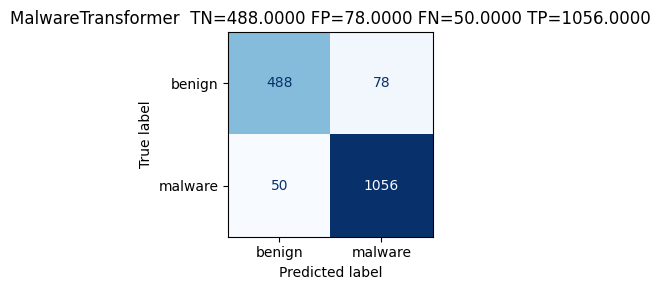

In [13]:
# ── Test Set Evaluation — Transformer ────────────────────────────────────────
_, _, _, test_probs, test_labels = run_epoch(test_dl, train=False)
test_preds = (test_probs >= THRESHOLD).astype(int)

print(f'=== MalwareTransformer (threshold={THRESHOLD:.2f}) ===')
print(classification_report(test_labels.astype(int), test_preds,
                             target_names=['benign', 'malware'],digits=4))
txf_auc  = roc_auc_score(test_labels, test_probs)
txf_ap   = average_precision_score(test_labels, test_probs)
txf_f1   = f1_score(test_labels.astype(int), test_preds, average='macro')
txf_prec = precision_score(test_labels.astype(int), test_preds, pos_label=1)
txf_rec  = recall_score(test_labels.astype(int), test_preds, pos_label=1)
print(f'ROC-AUC: {txf_auc:.4f}  |  Avg-Prec: {txf_ap:.4f}')

# Confusion matrix
cm = confusion_matrix(test_labels.astype(int), test_preds)
fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay(cm, display_labels=['benign', 'malware']).plot(ax=ax, colorbar=False, cmap='Blues')
tn, fp, fn, tp = cm.ravel()
ax.set_title(f'MalwareTransformer  TN={tn:.4f} FP={fp:.4f} FN={fn:.4f} TP={tp:.4f}')
plt.tight_layout()
plt.show()


In [14]:
# ── SSL Ablation — Pretrained Encoder vs Random Init ──────────────────────────
# Makale raporu için amaç: self-supervised ön-eğitimin katkısını aynı split,
# aynı mimari ve aynı supervised eğitim politikası altında ölçmek.
#
# Ana akış zaten SSL-pretrained modeli eğitip test ediyor. Bu hücre aynı mimariyi
# pretraining aktarmadan eğitir ve SSL katkısını ölçer.
# Not: Random-init encoder dondurulmaz; aksi halde rastgele ağırlıklar ilk
# epoch'larda öğrenemeyeceği için SSL lehine yapay bir avantaj oluşur.

ABLATION_EPOCHS   = EPOCHS
ABLATION_PATIENCE = PATIENCE


def build_model(use_ssl=True, use_bilstm=True, use_ngram=True):
    m = MalwareTransformer(use_bilstm=use_bilstm, use_ngram=use_ngram).to(DEVICE)
    if use_ssl:
        m.load_pretrained_encoder(pretrainer)
    else:
        print('Random-init model: SSL encoder aktarımı yapılmadı.')
    return m


def set_encoder_grad_for(m, requires_grad: bool):
    for p in m.tag_emb.parameters():    p.requires_grad_(requires_grad)
    for p in m.time_proj.parameters():  p.requires_grad_(requires_grad)
    for p in m.delta_proj.parameters(): p.requires_grad_(requires_grad)
    for p in m.burst_proj.parameters(): p.requires_grad_(requires_grad)
    for p in m.encoder.parameters():    p.requires_grad_(requires_grad)
    m.cls_token.requires_grad_(requires_grad)
    for p in m.input_norm.parameters(): p.requires_grad_(requires_grad)


def make_optimizer_for(m):
    enc_params = (
        list(m.tag_emb.parameters()) + list(m.time_proj.parameters()) +
        list(m.delta_proj.parameters()) + list(m.burst_proj.parameters()) +
        list(m.encoder.parameters()) + [m.cls_token] +
        list(m.input_norm.parameters())
    )
    head_params = list(m.freq_proj.parameters()) + list(m.head.parameters())
    if getattr(m, 'use_ngram', False):
        head_params += list(m.ngram_proj.parameters())

    param_groups = [{'params': enc_params, 'lr': ENCODER_LR}]
    if getattr(m, 'use_bilstm', False):
        lstm_params = list(m.bilstm.parameters()) + list(m.lstm_norm.parameters())
        param_groups.append({'params': lstm_params, 'lr': LSTM_LR})
    param_groups.append({'params': head_params, 'lr': HEAD_LR})

    return AdamW(param_groups, weight_decay=WEIGHT_DECAY)


def run_epoch_for(m, loader, criterion, optimizer=None, train=True):
    m.train(train)
    total_loss, all_probs, all_labels = 0.0, [], []
    with torch.set_grad_enabled(train):
        for batch in loader:
            (tag_ids, time_vals, delta_vals, burst_vals, pad_mask,
             tag_freq, ngram_feat, labels) = [b.to(DEVICE) for b in batch]

            logits = m(tag_ids, time_vals, delta_vals, burst_vals,
                       pad_mask, tag_freq, ngram_feat)
            targets = smooth_labels(labels) if train else labels
            loss = criterion(logits, targets)

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(m.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item() * len(labels)
            all_probs.extend(torch.sigmoid(logits).detach().cpu().numpy().tolist())
            all_labels.extend(labels.detach().cpu().numpy().tolist())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    auc = roc_auc_score(all_labels, all_probs)
    f1 = f1_score(all_labels, (all_probs >= 0.5).astype(int), average='macro')
    return total_loss / max(len(all_labels), 1), auc, f1, all_probs, all_labels


def train_model_variant(use_ssl=True, tag='ssl', use_bilstm=True, use_ngram=True):
    m = build_model(use_ssl=use_ssl, use_bilstm=use_bilstm, use_ngram=use_ngram)
    set_encoder_grad_for(m, not use_ssl)
    if use_ssl:
        print(f'[{tag}] pretrained encoder ilk {FREEZE_EPOCHS} epoch dondurulacak.')
    else:
        print(f'[{tag}] random-init encoder baştan eğitilecek.')

    opt = make_optimizer_for(m)
    sched = SequentialLR(
        opt,
        schedulers=[LinearLR(opt, start_factor=0.1, end_factor=1.0,
                             total_iters=WARMUP_EPOCHS),
                    CosineAnnealingLR(opt, T_max=ABLATION_EPOCHS - WARMUP_EPOCHS,
                                      eta_min=1e-6)],
        milestones=[WARMUP_EPOCHS],
    )

    best_auc, best_state_local, patience_count = 0.0, None, 0
    for epoch in range(1, ABLATION_EPOCHS + 1):
        if use_ssl and epoch == FREEZE_EPOCHS + 1:
            set_encoder_grad_for(m, True)

        tr_loss, tr_auc, _, _, _ = run_epoch_for(m, train_dl, criterion, optimizer=opt, train=True)
        vl_loss, vl_auc, vl_f1, _, _ = run_epoch_for(m, val_dl, criterion, train=False)
        sched.step()

        if vl_auc > best_auc:
            best_auc = vl_auc
            patience_count = 0
            best_state_local = {k: v.detach().cpu().clone() for k, v in m.state_dict().items()}
        else:
            patience_count += 1
            if patience_count >= ABLATION_PATIENCE:
                print(f'[{tag}] Early stop @ epoch {epoch}  best val AUC={best_auc:.4f}')
                break

        if epoch % 10 == 0 or epoch == 1:
            print(f'[{tag}] ep{epoch:>3}  tr_loss={tr_loss:.4f}  vl_loss={vl_loss:.4f}  '
                  f'tr_auc={tr_auc:.4f}  vl_auc={vl_auc:.4f}  vl_f1@0.5={vl_f1:.4f}')

    assert best_state_local is not None, f'{tag}: checkpoint yakalanmadı.'
    m.load_state_dict(best_state_local)
    m.to(DEVICE)

    _, _, _, val_probs_local, val_labels_local = run_epoch_for(m, val_dl, criterion, train=False)
    thr, val_f1 = find_best_threshold(val_labels_local, val_probs_local)
    _, _, _, test_probs_local, test_labels_local = run_epoch_for(m, test_dl, criterion, train=False)
    test_preds_local = (test_probs_local >= thr).astype(int)

    return {
        'variant': tag,
        'use_ssl': use_ssl,
        'use_bilstm': use_bilstm,
        'use_ngram': use_ngram,
        'val_auc': roc_auc_score(val_labels_local, val_probs_local),
        'val_f1': val_f1,
        'threshold': thr,
        'test_auc': roc_auc_score(test_labels_local, test_probs_local),
        'test_ap': average_precision_score(test_labels_local, test_probs_local),
        'test_f1': f1_score(test_labels_local.astype(int), test_preds_local, average='macro'),
        'test_prec': precision_score(test_labels_local.astype(int), test_preds_local, pos_label=1, zero_division=0),
        'test_rec': recall_score(test_labels_local.astype(int), test_preds_local, pos_label=1, zero_division=0),
    }


ssl_ablation_results = [
    {
        'variant': 'ssl_pretrained_main',
        'use_ssl': True,
        'use_bilstm': True,
        'use_ngram': True,
        'val_auc': max(history['val_auc']),
        'val_f1': val_f1_opt,
        'threshold': THRESHOLD,
        'test_auc': txf_auc,
        'test_ap': txf_ap,
        'test_f1': txf_f1,
        'test_prec': txf_prec,
        'test_rec': txf_rec,
    },
    train_model_variant(use_ssl=False, tag='random_init'),
]

df_ssl_ablation = pd.DataFrame(ssl_ablation_results)
print('\n=== SSL Ablation: pretrained vs random init ===')
print(df_ssl_ablation.to_string(index=False, float_format='{:.4f}'.format))


Random-init model: SSL encoder aktarımı yapılmadı.
[random_init] random-init encoder baştan eğitilecek.
[random_init] ep  1  tr_loss=0.4445  vl_loss=0.3062  tr_auc=0.7415  vl_auc=0.8702  vl_f1@0.5=0.7716
[random_init] ep 10  tr_loss=0.2515  vl_loss=0.1756  tr_auc=0.9690  vl_auc=0.9620  vl_f1@0.5=0.8892
[random_init] ep 20  tr_loss=0.2100  vl_loss=0.1516  tr_auc=0.9900  vl_auc=0.9715  vl_f1@0.5=0.9082
[random_init] ep 30  tr_loss=0.1899  vl_loss=0.1491  tr_auc=0.9954  vl_auc=0.9710  vl_f1@0.5=0.9243
[random_init] ep 40  tr_loss=0.1750  vl_loss=0.1563  tr_auc=0.9985  vl_auc=0.9698  vl_f1@0.5=0.9166
[random_init] ep 50  tr_loss=0.1687  vl_loss=0.1552  tr_auc=0.9990  vl_auc=0.9696  vl_f1@0.5=0.9255
[random_init] Early stop @ epoch 53  best val AUC=0.9741

=== SSL Ablation: pretrained vs random init ===
            variant  use_ssl  use_bilstm  use_ngram  val_auc  val_f1  threshold  test_auc  test_ap  test_f1  test_prec  test_rec
ssl_pretrained_main     True        True       True   0.9783 

In [15]:
# ── Architectural Ablation — Branch Contribution ─────────────────────────────
# Amaç: N-gram ve BiLSTM branch'lerinin katkısını aynı split, aynı SSL encoder
# ve aynı fine-tuning politikası altında ölçmek. Bir branch katkı vermiyorsa
# makale anlatımında iddia edilmemeli; gerekirse modelden çıkarılmalıdır.

arch_ablation_results = [
    {
        'variant': 'full_model',
        'use_ssl': True,
        'use_bilstm': True,
        'use_ngram': True,
        'val_auc': max(history['val_auc']),
        'val_f1': val_f1_opt,
        'threshold': THRESHOLD,
        'test_auc': txf_auc,
        'test_ap': txf_ap,
        'test_f1': txf_f1,
        'test_prec': txf_prec,
        'test_rec': txf_rec,
    },
    train_model_variant(use_ssl=True, tag='without_ngram', use_bilstm=True,  use_ngram=False),
    train_model_variant(use_ssl=True, tag='without_bilstm', use_bilstm=False, use_ngram=True),
]

df_arch_ablation = pd.DataFrame(arch_ablation_results)
print('\n=== Architectural Ablation: branch contribution ===')
print(df_arch_ablation.to_string(index=False, float_format='{:.4f}'.format))

base_auc = df_arch_ablation.loc[df_arch_ablation['variant'] == 'full_model', 'test_auc'].iloc[0]
base_f1  = df_arch_ablation.loc[df_arch_ablation['variant'] == 'full_model', 'test_f1'].iloc[0]
df_arch_delta = df_arch_ablation.copy()
df_arch_delta['delta_test_auc'] = df_arch_delta['test_auc'] - base_auc
df_arch_delta['delta_test_f1']  = df_arch_delta['test_f1'] - base_f1
print('\nDelta vs full model:')
print(df_arch_delta[['variant','delta_test_auc','delta_test_f1']]
      .to_string(index=False, float_format='{:+.4f}'.format))


Pretrained encoder ağırlıkları MalwareTransformer modeline aktarıldı.
Sıfırdan eğitilecek branch/head: freq/head, BiLSTM
[without_ngram] pretrained encoder ilk 5 epoch dondurulacak.
[without_ngram] ep  1  tr_loss=0.4503  vl_loss=0.3138  tr_auc=0.7287  vl_auc=0.8619  vl_f1@0.5=0.7425
[without_ngram] ep 10  tr_loss=0.2580  vl_loss=0.1734  tr_auc=0.9658  vl_auc=0.9691  vl_f1@0.5=0.8886
[without_ngram] ep 20  tr_loss=0.2230  vl_loss=0.1406  tr_auc=0.9852  vl_auc=0.9786  vl_f1@0.5=0.9114
[without_ngram] ep 30  tr_loss=0.2033  vl_loss=0.1371  tr_auc=0.9923  vl_auc=0.9775  vl_f1@0.5=0.9209
[without_ngram] ep 40  tr_loss=0.1874  vl_loss=0.1345  tr_auc=0.9965  vl_auc=0.9786  vl_f1@0.5=0.9210
[without_ngram] ep 50  tr_loss=0.1789  vl_loss=0.1332  tr_auc=0.9980  vl_auc=0.9780  vl_f1@0.5=0.9270
[without_ngram] ep 60  tr_loss=0.1717  vl_loss=0.1332  tr_auc=0.9990  vl_auc=0.9790  vl_f1@0.5=0.9263
[without_ngram] Early stop @ epoch 66  best val AUC=0.9801
Pretrained encoder ağırlıkları MalwareTransfo